In [5]:

import matplotlib.pyplot as plt
import json
import os 
# Set project root so relative paths (e.g. routing_performance.json) work
ROOT = "/data/gpfs/projects/punim2662/routing_system"
os.chdir(ROOT)
print(f"Working directory: {os.getcwd()}")

Working directory: /data/gpfs/projects/punim2662/routing_system


In [6]:
import json
with open('performance_data_vicuna_13b_final.json', 'rb') as f:
    data = json.load(f)
print(len(data))


300


# Plot when load and thread percentage varries

In [7]:
failed_rows = []
success_rows = []


for row in data:
    if 'failed' not in row['result']:
        success_rows.append(row)
        # print(row['setup']['tensor_parallel_size'])
    else:
        failed_rows.append(row)

print(f'success rows: {len(success_rows)}')
print(f'failed rows: {len(failed_rows)}')


success rows: 300
failed rows: 0


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Config
# ---------------------------
TP_FILTER = 4
SELECTED_IDX = [1, 2, 4, 5]
FIGSIZE = (4, 3)
# fig, ax = plt.subplots(figsize=FIGSIZE)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 1.8,
    "lines.markersize": 5.2,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ---------------------------
# Build grouped data
# ---------------------------
rows_tp = [
    row for row in success_rows
    if int(row["setup"]["tensor_parallel_size"]) == TP_FILTER
    and int(row["setup"]["thread_percentage"]) >= MIN_THREAD_PCT
]

# load_rps -> thread_percentage -> list[p95_ttft]
p95_by_load_thread = {}
for row in rows_tp:
    setup = row.get("setup", {})
    result = row.get("result", {})
    ttfts = result.get("ttfts_ms")
    if not ttfts:
        continue

    load = float(setup["load_rps"])
    thread = int(setup["thread_percentage"])
    p95 = float(np.percentile(ttfts, 95))

    p95_by_load_thread.setdefault(load, {}).setdefault(thread, []).append(p95)

all_loads = sorted(p95_by_load_thread.keys())
selected_loads = [all_loads[i] for i in SELECTED_IDX if i < len(all_loads)]

if not selected_loads:
    raise ValueError("No selected loads. Check SELECTED_IDX and available loads.")

# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)

# Muted colors that also separate reasonably in grayscale
colors = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#8c564b", "#ff7f0e"]
linestyles = ["-", "--", "-.", ":"]
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]

for i, load in enumerate(selected_loads):
    thread_map = p95_by_load_thread[load]
    threads = sorted(thread_map.keys())
    p95_avg = [float(np.mean(thread_map[t])) for t in threads]

    ax.plot(
        threads,
        p95_avg,
        color=colors[i % len(colors)],
        linestyle=linestyles[i % len(linestyles)],
        marker=markers[i % len(markers)],
        markerfacecolor="white",
        markeredgecolor=colors[i % len(colors)],
        markeredgewidth=1.0,
        label=f"{load:.2f} RPS",
    )

ax.set_xlabel("GPU thread percentage (%)")
ax.set_ylabel("P95 TTFT (ms)")

# Better than a title for papers; put context in caption instead
# ax.set_title(f"P95 TTFT vs Thread Percentage (TP={TP_FILTER})")

ax.grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.35)
ax.set_axisbelow(True)

legend = ax.legend(
    title="Traffic load",
    loc="best",
    frameon=True,
    fancybox=False,
    edgecolor="0.8",
    facecolor="white",
    framealpha=1.0,
    ncol=2 if len(selected_loads) >= 4 else 1,
)

plt.tight_layout()
plt.savefig("./plots/p95_ttft_vs_thread_percentage_tp4.pdf", format="pdf", bbox_inches="tight")
plt.show()


print("All loads:", [round(x, 3) for x in all_lx    oads])
print("Selected indices:", SELECTED_IDX)
print("Selected loads:", [round(x, 3) for x in selected_loads])

SyntaxError: invalid syntax (41173772.py, line 115)

dict_keys(['timestamp', 'config', 'performance', 'ttfts_ms', 'tpot_ms_list', 'metrics_before', 'metrics_after'])
tp: 4, ttft: 417.10426572473654, length: 100
tp: 2, ttft: 1320.8672830322657, length: 100
tp: 1, ttft: 2660.831716989514, length: 100
thread: 10, ttft: 8000.142418188869, length: 30
thread: 20, ttft: 4171.310116296357, length: 30
thread: 30, ttft: 1326.4551963224644, length: 30
thread: 40, ttft: 547.4828306657593, length: 30
thread: 50, ttft: 261.3181723606445, length: 30
thread: 60, ttft: 127.59903441036097, length: 30
thread: 70, ttft: 81.78848161379636, length: 30
thread: 80, ttft: 60.585765357990326, length: 30
thread: 90, ttft: 46.334684309449095, length: 30
thread: 100, ttft: 39.66085296269923, length: 30
load: 1.0, ttft: 36.13124264386638, length: 30
load: 3.111111111111111, ttft: 113.31116220832305, length: 30
load: 5.222222222222222, ttft: 304.16828302686076, length: 30
load: 7.333333333333334, ttft: 716.3538598861745, length: 30
load: 9.444444444444445, ttft: 1093.

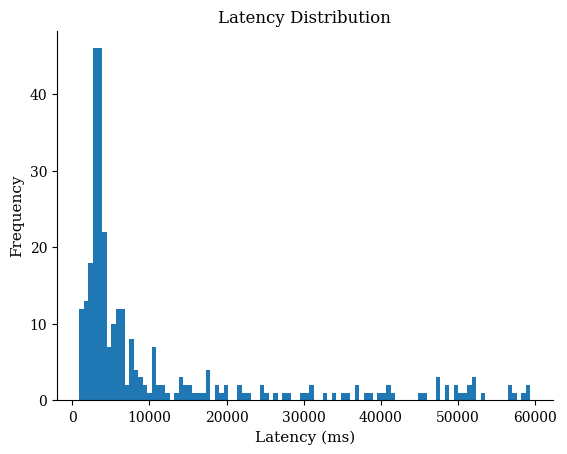

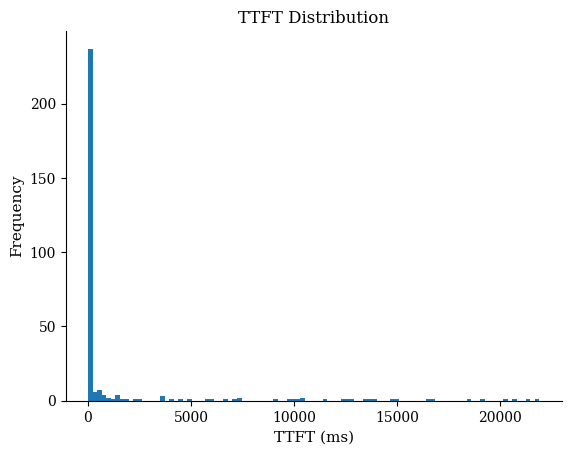

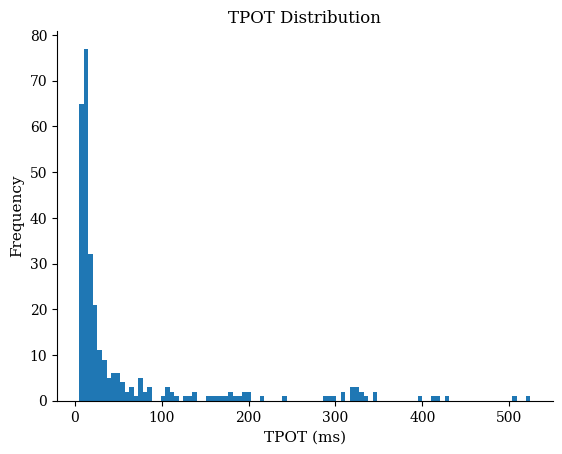

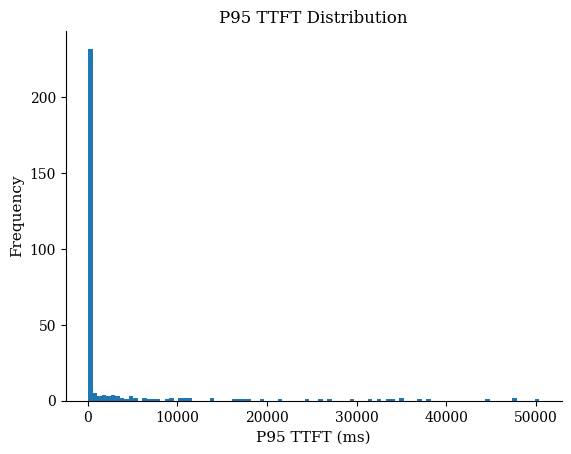

In [ ]:
import numpy as np

print(success_rows[0]['result'].keys())
latencies = []
ttfts = []
ttft_per_tp = {}
ttft_per_thread = {}
ttft_per_load = {}
p95_ttfts = []
tpots = []
for row in success_rows:
    latencies.append(row['result']['performance']['p99_latency_ms'])
    ttfts.append(np.mean(row['result']['ttfts_ms']))
    tpots.append(np.mean(row['result']['tpot_ms_list']))
    p95_ttfts.append(np.percentile(row['result']['ttfts_ms'], 95))
    if row['setup']['tensor_parallel_size'] not in ttft_per_tp:
        ttft_per_tp[row['setup']['tensor_parallel_size']] = []
    ttft_per_tp[row['setup']['tensor_parallel_size']].append(np.mean(row['result']['ttfts_ms']))
    if row['setup']['thread_percentage'] not in ttft_per_thread:
        ttft_per_thread[row['setup']['thread_percentage']] = []
    if row['setup']['load_rps'] not in ttft_per_load:
        ttft_per_load[row['setup']['load_rps']] = []
    ttft_per_load[row['setup']['load_rps']].append(np.mean(row['result']['ttfts_ms']))
    ttft_per_thread[row['setup']['thread_percentage']].append(np.mean(row['result']['ttfts_ms']))


for tp in ttft_per_tp:
    print(f'tp: {tp}, ttft: {np.mean(ttft_per_tp[tp])}, length: {len(ttft_per_tp[tp])}')

for thread in ttft_per_thread:
    print(f'thread: {thread}, ttft: {np.mean(ttft_per_thread[thread])}, length: {len(ttft_per_thread[thread])}')

for load in ttft_per_load:
    print(f'load: {load}, ttft: {np.mean(ttft_per_load[load])}, length: {len(ttft_per_load[load])}')

throughput_to_load = []
for row in success_rows:
    throughput_to_load.append(row['result']['performance']['throughput_rps']/row['setup']['load_rps'])
    throughput_to_load.append(np.mean(row['result']['ttfts_ms']))

print(f'ttft: {np.mean(ttfts)}')
print(f'ttft standard deviation: {np.std(ttfts)}')
print(f'tpot: {np.mean(tpots)}')
print(f'tpot standard deviation: {np.std(tpots)}s')



plt.hist(latencies, bins=100)
plt.title('Latency Distribution')
plt.xlabel('Latency (ms)')
plt.ylabel('Frequency')
plt.show()
plt.hist(ttfts, bins=100)
plt.title('TTFT Distribution')
plt.xlabel('TTFT (ms)')
plt.ylabel('Frequency')
plt.show()
plt.hist(tpots, bins=100)
plt.title('TPOT Distribution')
plt.xlabel('TPOT (ms)')
plt.ylabel('Frequency')
plt.show()
plt.hist(p95_ttfts, bins=100)
plt.title('P95 TTFT Distribution')
plt.xlabel('P95 TTFT (ms)')
plt.ylabel('Frequency')
plt.show()

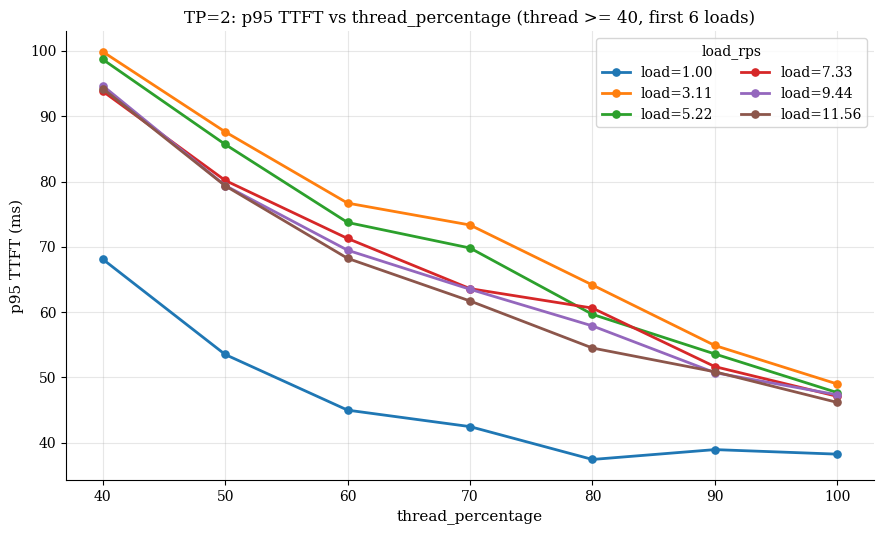

Selected loads: [1.0, 3.111, 5.222, 7.333, 9.444, 11.556]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

TP_FILTER = 2
MIN_THREAD_PCT = 40
NUM_LOADS_TO_SHOW = 6

rows_tp = [
    row for row in success_rows
    if row['setup']['tensor_parallel_size'] == TP_FILTER
    and int(row['setup']['thread_percentage']) >= MIN_THREAD_PCT
]

# load_rps -> thread_percentage -> list[p95_ttft]
p95_by_load_thread = {}
for row in rows_tp:
    setup = row.get('setup', {})
    result = row.get('result', {})
    ttfts = result.get('ttfts_ms')
    if not ttfts:
        continue

    load = float(setup['load_rps'])
    thread = int(setup['thread_percentage'])
    p95 = float(np.percentile(ttfts, 95))
    p95_by_load_thread.setdefault(load, {}).setdefault(thread, []).append(p95)

all_loads = sorted(p95_by_load_thread.keys())

# Select load indices in order from the sorted load list (0-based).
# Example: [0,1,2,3,4,5] picks the first 6 loads.
selected_idx = [0, 1, 2, 3, 4, 5]
selected_loads = [all_loads[i] for i in selected_idx if i < len(all_loads)]

plt.figure(figsize=(9, 5.5))
for load in selected_loads:
    thread_map = p95_by_load_thread[load]
    threads = sorted(thread_map.keys())
    p95_avg = [float(np.mean(thread_map[t])) for t in threads]
    plt.plot(threads, p95_avg, marker='o', linewidth=2, label=f'load={load:.2f}')

plt.title(
    f'TP={TP_FILTER}: p95 TTFT vs thread_percentage '
    f'(thread >= {MIN_THREAD_PCT}, first {NUM_LOADS_TO_SHOW} loads)'
)
plt.xlabel('thread_percentage')
plt.ylabel('p95 TTFT (ms)')
plt.grid(alpha=0.3)
plt.legend(title='load_rps', ncol=2)
plt.tight_layout()
plt.show()

print('Selected loads:', [round(x, 3) for x in selected_loads])

SetupCandidate(subset=(0, 1), tp_levels=[2, 2], thread_levels=[80, 100], memory_levels=[0.2, 0.5], best_beta=0.04746093750000001, best_score=0.474155931048516, best_latency=544.6985848757174, best_slack=-0.009638936589604685, alpha=[-0.28195193667349167, 0.28195193667349167], packing_feasible=True, slo_feasible=True)
best score: 0.5525403501979537
best latency: 65.08735555144226


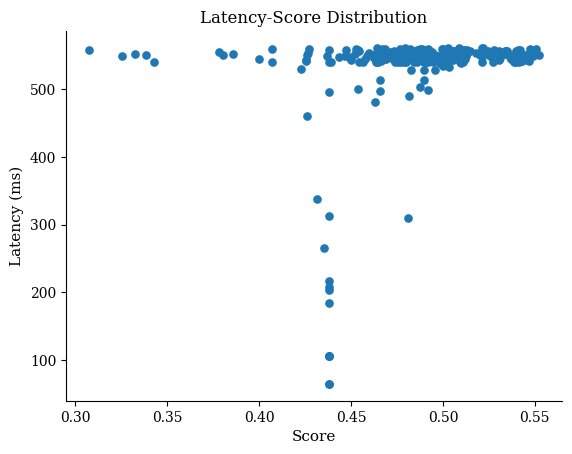

In [ ]:
from resource_allocation.brute_force_setup import load_result

data = load_result('resource_allocation/brute_force_lam80_tau600.pkl')
feasible_data = data.all_feasible
print(feasible_data[0])
latencies = []
scores = []
for row in feasible_data:
    latencies.append(row.best_latency)
    scores.append(row.best_score)

# print the best score and latency
print(f'best score: {max(scores)}')
print(f'best latency: {min(latencies)}')

# plot the latency-score distribution
plt.scatter(scores, latencies)
plt.title('Latency-Score Distribution')
plt.xlabel('Score')
plt.ylabel('Latency (ms)')
plt.show()
